**Sub questions:** Write a zoom function supporting:
- **(a)** Nearest-neighbor interpolation
- **(b)** Bilinear interpolation

In [29]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('../outputs/q7', exist_ok=True)
ZOOM_DIR = '../images/a1images/a1q8images'


## Core Zoom Function

In [30]:
def zoom_image(image, scale, method='bilinear', out_size=None):
    """
    Zoom a grayscale image by a given scale factor using inverse mapping.

    Parameters:
        image    : np.ndarray — input grayscale uint8 image, shape (H, W)
        scale    : float      — zoom factor s in (0, 10]; >1 enlarges, <1 shrinks
        method   : str        — 'nearest' or 'bilinear'
        out_size : tuple      — (out_H, out_W) to override computed output size.
                                Useful when the exact target size is known.

    Returns:
        output   : np.ndarray — zoomed uint8 image
    """
    assert scale > 0, "Scale must be positive (range: (0,10]; ×20 test case allowed via out_size)"
    assert method in ('nearest', 'bilinear'), f"Unknown method: {method}"

    H, W = image.shape

    # Output dimensions
    if out_size is not None:
        out_H, out_W = out_size
    else:
        out_H = int(round(H * scale))
        out_W = int(round(W * scale))

    output = np.zeros((out_H, out_W), dtype=np.uint8)

    # Build output pixel coordinate grids (vectorized — fast)
    out_rows = np.arange(out_H)          # [0, 1, ..., out_H-1]
    out_cols = np.arange(out_W)          # [0, 1, ..., out_W-1]

    # Map output coordinates back to source (inverse mapping)
    src_rows_f = out_rows / scale        # floating-point source row coords
    src_cols_f = out_cols / scale        # floating-point source col coords

    if method == 'nearest':
        # ── Nearest-neighbor ──────────────────────────────────────────────────
        # Round to nearest integer source pixel
        r_idx = np.clip(np.round(src_rows_f).astype(int), 0, H - 1)
        c_idx = np.clip(np.round(src_cols_f).astype(int), 0, W - 1)

        # Apply mapping using NumPy advanced indexing
        # r_idx[:, None] broadcasts rows; c_idx[None, :] broadcasts cols
        output = image[r_idx[:, None], c_idx[None, :]]

    elif method == 'bilinear':
        # ── Bilinear interpolation ────────────────────────────────────────────
        # Floor and ceil of source coordinates
        r0 = np.clip(np.floor(src_rows_f).astype(int), 0, H - 1)
        r1 = np.clip(r0 + 1,                           0, H - 1)
        c0 = np.clip(np.floor(src_cols_f).astype(int), 0, W - 1)
        c1 = np.clip(c0 + 1,                           0, W - 1)

        # Fractional parts (weight for interpolation)
        dr = (src_rows_f - np.floor(src_rows_f))[:, None]  # shape (out_H, 1)
        dc = (src_cols_f - np.floor(src_cols_f))[None, :]  # shape (1, out_W)

        # Four corner pixel values — shape (out_H, out_W) each
        I_r0c0 = image[r0[:, None], c0[None, :]].astype(np.float64)
        I_r0c1 = image[r0[:, None], c1[None, :]].astype(np.float64)
        I_r1c0 = image[r1[:, None], c0[None, :]].astype(np.float64)
        I_r1c1 = image[r1[:, None], c1[None, :]].astype(np.float64)

        # Bilinear formula
        output = (
            (1 - dr) * (1 - dc) * I_r0c0 +
            (1 - dr) *      dc  * I_r0c1 +
                 dr  * (1 - dc) * I_r1c0 +
                 dr  *      dc  * I_r1c1
        )
        output = np.clip(np.round(output), 0, 255).astype(np.uint8)

    return output


def normalized_ssd(imgA, imgB):
    """
    Compute normalized Sum of Squared Differences between two same-size images.
    Both images must have the same shape.
    Returns a float — lower is better.
    """
    assert imgA.shape == imgB.shape, (
        f"Shape mismatch: {imgA.shape} vs {imgB.shape}")
    diff  = imgA.astype(np.float64) - imgB.astype(np.float64)
    return np.sum(diff ** 2) / imgA.size


print("zoom_image() and normalized_ssd() functions defined.")


zoom_image() and normalized_ssd() functions defined.


In [31]:
# ── Quick sanity check: zoom a tiny test image ───────────────────────────────
test_img = np.array([[10, 20, 30],
                     [40, 50, 60],
                     [70, 80, 90]], dtype=np.uint8)

nn_2x = zoom_image(test_img, scale=2.0, method='nearest')
bl_2x = zoom_image(test_img, scale=2.0, method='bilinear')

print("Test image (3×3):")
print(test_img)
print()
print("Nearest-neighbor 2× zoom (6×6):")
print(nn_2x)
print()
print("Bilinear 2× zoom (6×6):")
print(bl_2x)
print()
print(f"NN shape    : {nn_2x.shape}  ✓" if nn_2x.shape==(6,6) else "SHAPE ERROR")
print(f"Bilin shape : {bl_2x.shape}  ✓" if bl_2x.shape==(6,6) else "SHAPE ERROR")


Test image (3×3):
[[10 20 30]
 [40 50 60]
 [70 80 90]]

Nearest-neighbor 2× zoom (6×6):
[[10 10 20 30 30 30]
 [10 10 20 30 30 30]
 [40 40 50 60 60 60]
 [70 70 80 90 90 90]
 [70 70 80 90 90 90]
 [70 70 80 90 90 90]]

Bilinear 2× zoom (6×6):
[[10 15 20 25 30 30]
 [25 30 35 40 45 45]
 [40 45 50 55 60 60]
 [55 60 65 70 75 75]
 [70 75 80 85 90 90]
 [70 75 80 85 90 90]]

NN shape    : (6, 6)  ✓
Bilin shape : (6, 6)  ✓


## Apply to All Image Pairs and Compute SSD

In [32]:
# ── Define all image pairs ───────────────────────────────────────────────────
pairs = [
    ('im01small.png',         'im01.png',    4.0),
    ('im02small.png',         'im02.png',    4.0),
    ('im03small.png',         'im03.png',    4.0),   # slight non-integer — use out_size
    ('taylor_small.jpg',      'taylor.jpg',  5.0),
    ('taylor_very_small.jpg', 'taylor.jpg',  20.0),
]

results = []

print(f"{'Small Image':<28} {'Scale':>6} {'SSD (NN)':>12} {'SSD (Bilinear)':>16} {'Winner':>10}")
print("-" * 78)

for small_name, large_name, scale in pairs:
    # Load images
    small = cv.imread(os.path.join(ZOOM_DIR, small_name), cv.IMREAD_GRAYSCALE)
    large = cv.imread(os.path.join(ZOOM_DIR, large_name), cv.IMREAD_GRAYSCALE)

    assert small is not None, f"Could not load {small_name}"
    assert large is not None, f"Could not load {large_name}"

    # Target output size = exact size of the large original
    out_size = (large.shape[0], large.shape[1])

    # Zoom with both methods
    zoomed_nn = zoom_image(small, scale, method='nearest',  out_size=out_size)
    zoomed_bl = zoom_image(small, scale, method='bilinear', out_size=out_size)

    # Compute normalized SSD against original
    ssd_nn = normalized_ssd(zoomed_nn, large)
    ssd_bl = normalized_ssd(zoomed_bl, large)

    winner = 'Bilinear' if ssd_bl < ssd_nn else 'Nearest'

    results.append({
        'small': small_name, 'large': large_name, 'scale': scale,
        'small_img': small,  'large_img': large,
        'nn': zoomed_nn,     'bl': zoomed_bl,
        'ssd_nn': ssd_nn,    'ssd_bl': ssd_bl,
    })

    print(f"{small_name:<28} {scale:>6.1f}×  {ssd_nn:>12.2f} {ssd_bl:>16.2f} {winner:>10}")


Small Image                   Scale     SSD (NN)   SSD (Bilinear)     Winner
------------------------------------------------------------------------------
im01small.png                   4.0×        256.82           201.35   Bilinear
im02small.png                   4.0×         65.42            49.65   Bilinear
im03small.png                   4.0×        126.33            95.87   Bilinear
taylor_small.jpg                5.0×        319.31           286.68   Bilinear
taylor_very_small.jpg          20.0×        721.89           646.06   Bilinear


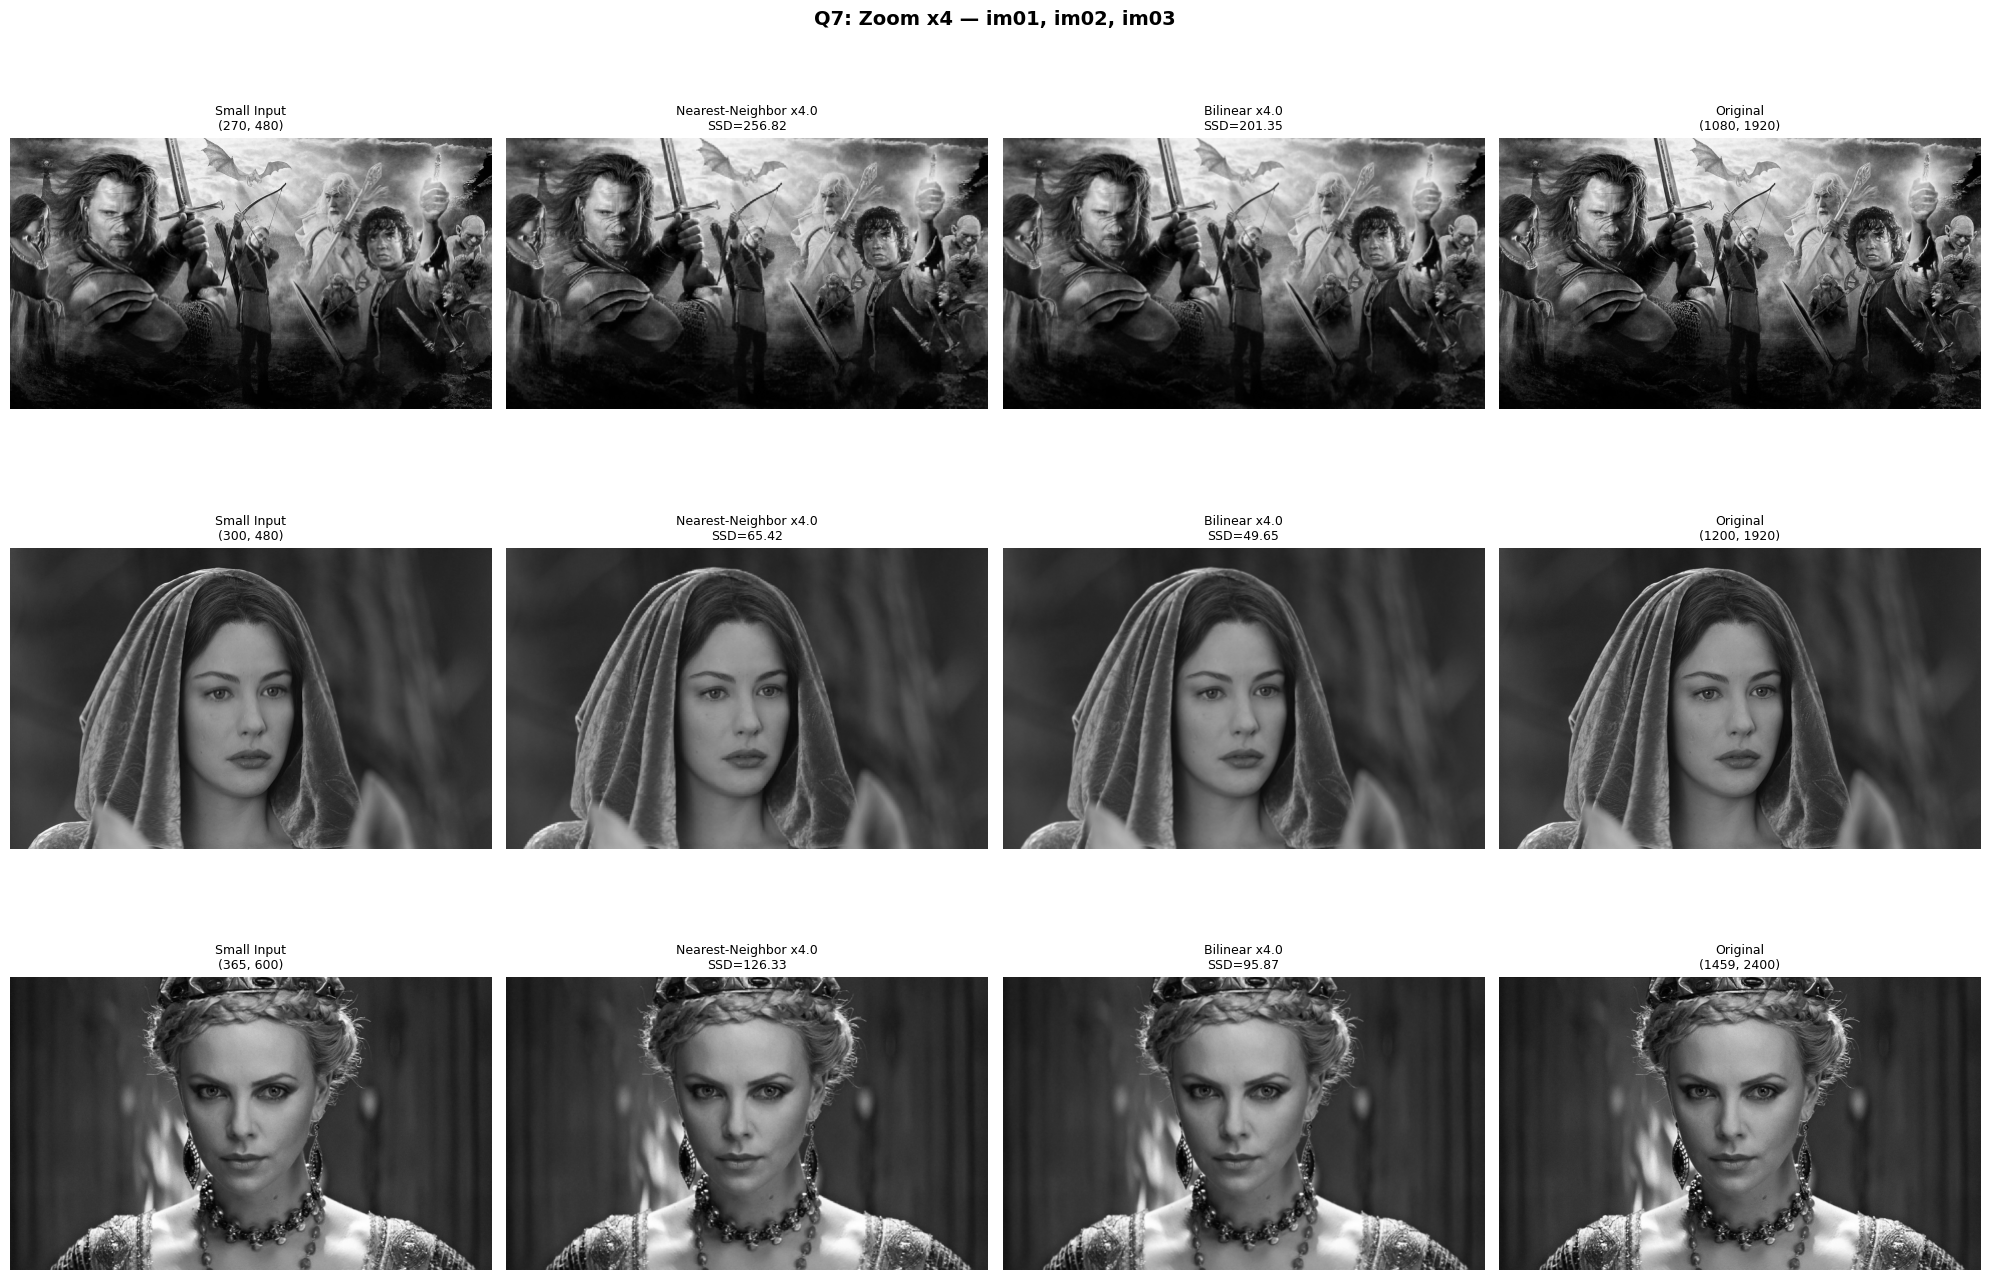

Saved q7_im01_im02_im03_comparison.png


In [33]:
# ── Visual comparison — im01, im02, im03 (scale x4) ─────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
fig.suptitle('Q7: Zoom x4 — im01, im02, im03', fontsize=14, fontweight='bold')

row_labels = ['im01small  →  im01', 'im02small  →  im02', 'im03small  →  im03']

for row, idx in enumerate([0, 1, 2]):
    r          = results[idx]
    ssd_nn_v   = r['ssd_nn']
    ssd_bl_v   = r['ssd_bl']
    scale_val  = r['scale']
    sml_shape  = r['small_img'].shape
    lrg_shape  = r['large_img'].shape

    axes[row, 0].imshow(r['small_img'],  cmap='gray', vmin=0, vmax=255)
    axes[row, 0].set_title('Small Input\n{}'.format(sml_shape), fontsize=9)
    axes[row, 0].axis('off')
    axes[row, 0].set_ylabel(row_labels[row], fontsize=9)

    axes[row, 1].imshow(r['nn'],         cmap='gray', vmin=0, vmax=255)
    axes[row, 1].set_title('Nearest-Neighbor x{}\nSSD={:.2f}'.format(scale_val, ssd_nn_v), fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(r['bl'],         cmap='gray', vmin=0, vmax=255)
    axes[row, 2].set_title('Bilinear x{}\nSSD={:.2f}'.format(scale_val, ssd_bl_v), fontsize=9)
    axes[row, 2].axis('off')

    axes[row, 3].imshow(r['large_img'],  cmap='gray', vmin=0, vmax=255)
    axes[row, 3].set_title('Original\n{}'.format(lrg_shape), fontsize=9)
    axes[row, 3].axis('off')

plt.tight_layout()
plt.savefig('../outputs/q7/q7_im01_im02_im03_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved q7_im01_im02_im03_comparison.png')


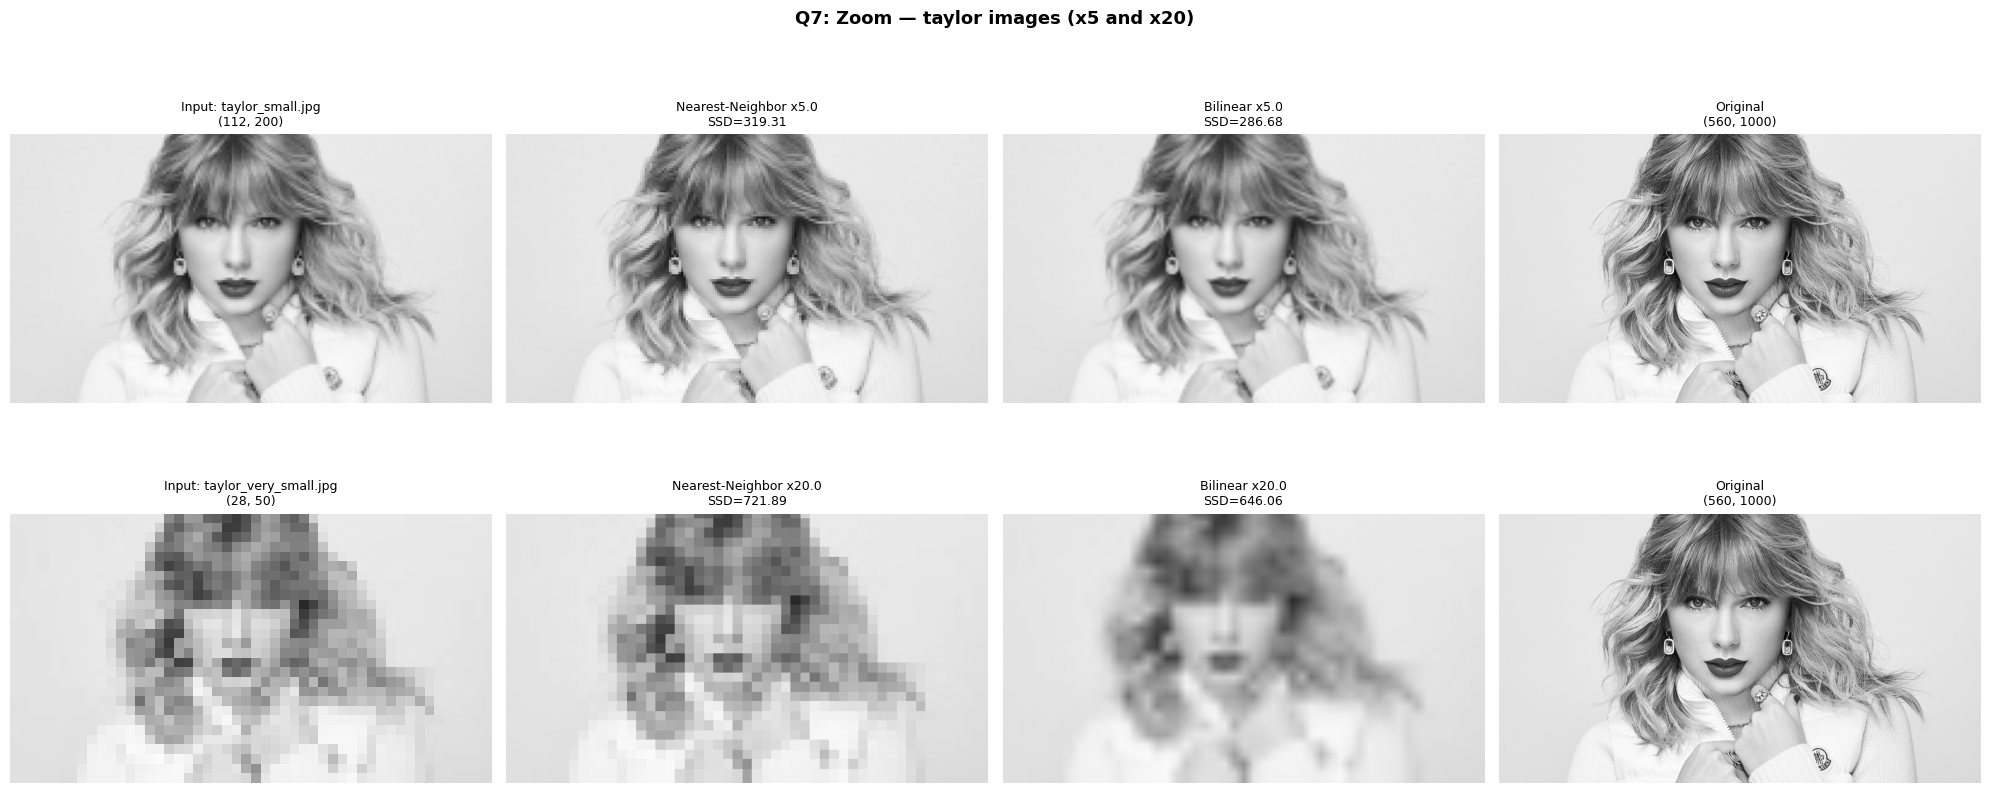

Saved q7_taylor_comparison.png


In [34]:
# ── Visual comparison — taylor_small (x5) and taylor_very_small (x20) ────────
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Q7: Zoom — taylor images (x5 and x20)', fontsize=13, fontweight='bold')

for row, idx in enumerate([3, 4]):
    r          = results[idx]
    scale_val  = r['scale']
    small_name = r['small']
    sml_shape  = r['small_img'].shape
    lrg_shape  = r['large_img'].shape
    ssd_nn_v   = r['ssd_nn']
    ssd_bl_v   = r['ssd_bl']

    axes[row, 0].imshow(r['small_img'],  cmap='gray', vmin=0, vmax=255)
    axes[row, 0].set_title('Input: {}\n{}'.format(small_name, sml_shape), fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(r['nn'],         cmap='gray', vmin=0, vmax=255)
    axes[row, 1].set_title('Nearest-Neighbor x{}\nSSD={:.2f}'.format(scale_val, ssd_nn_v), fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(r['bl'],         cmap='gray', vmin=0, vmax=255)
    axes[row, 2].set_title('Bilinear x{}\nSSD={:.2f}'.format(scale_val, ssd_bl_v), fontsize=9)
    axes[row, 2].axis('off')

    axes[row, 3].imshow(r['large_img'],  cmap='gray', vmin=0, vmax=255)
    axes[row, 3].set_title('Original\n{}'.format(lrg_shape), fontsize=9)
    axes[row, 3].axis('off')

plt.tight_layout()
plt.savefig('../outputs/q7/q7_taylor_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved q7_taylor_comparison.png')


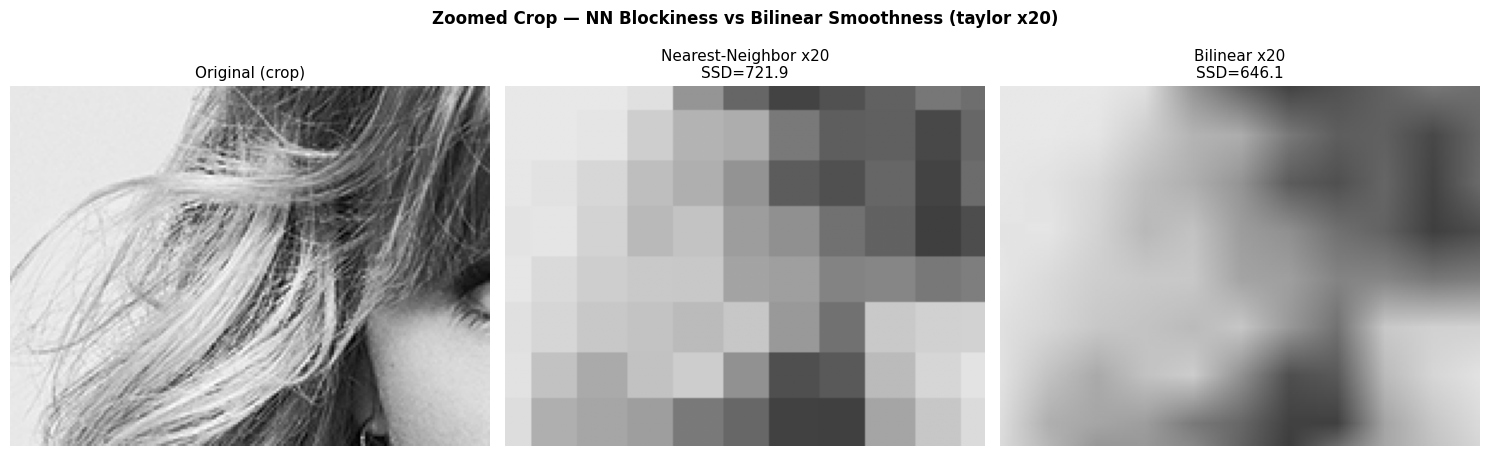

In [35]:
# ── Zoomed crop — show NN blockiness vs bilinear smoothness ─────────────────
r        = results[4]   # taylor_very_small, x20 zoom
ssd_nn_v = r['ssd_nn']
ssd_bl_v = r['ssd_bl']
crop     = np.s_[100:250, 200:400]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Zoomed Crop — NN Blockiness vs Bilinear Smoothness (taylor x20)',
             fontsize=12, fontweight='bold')

axes[0].imshow(r['large_img'][crop], cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original (crop)', fontsize=11)
axes[0].axis('off')

axes[1].imshow(r['nn'][crop],        cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Nearest-Neighbor x20\nSSD={:.1f}'.format(ssd_nn_v), fontsize=11)
axes[1].axis('off')

axes[2].imshow(r['bl'][crop],        cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Bilinear x20\nSSD={:.1f}'.format(ssd_bl_v), fontsize=11)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('../outputs/q7/q7_crop_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


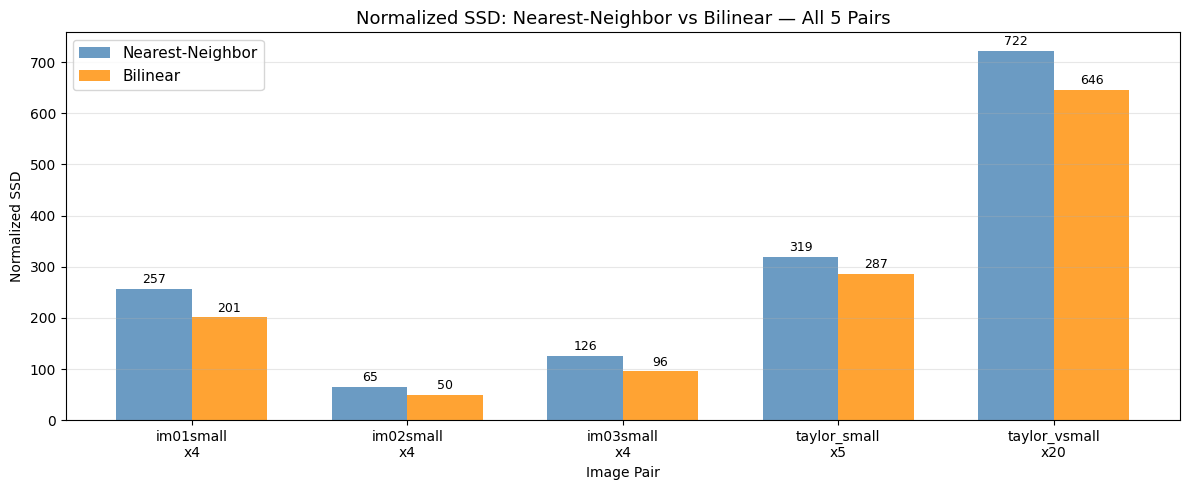

Saved q7_ssd_chart.png


In [36]:
# ── Bar chart of SSD results — all 5 image pairs ────────────────────────────
labels  = ['im01small\nx4', 'im02small\nx4', 'im03small\nx4',
           'taylor_small\nx5', 'taylor_vsmall\nx20']
ssd_nn  = [r['ssd_nn'] for r in results]
ssd_bl  = [r['ssd_bl'] for r in results]

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars_nn = ax.bar(x - w/2, ssd_nn, w, label='Nearest-Neighbor', color='steelblue',  alpha=0.8)
bars_bl = ax.bar(x + w/2, ssd_bl, w, label='Bilinear',         color='darkorange', alpha=0.8)

ax.set_xlabel('Image Pair')
ax.set_ylabel('Normalized SSD')
ax.set_title('Normalized SSD: Nearest-Neighbor vs Bilinear — All 5 Pairs', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in list(bars_nn) + list(bars_bl):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            '{:.0f}'.format(bar.get_height()),
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/q7/q7_ssd_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved q7_ssd_chart.png')


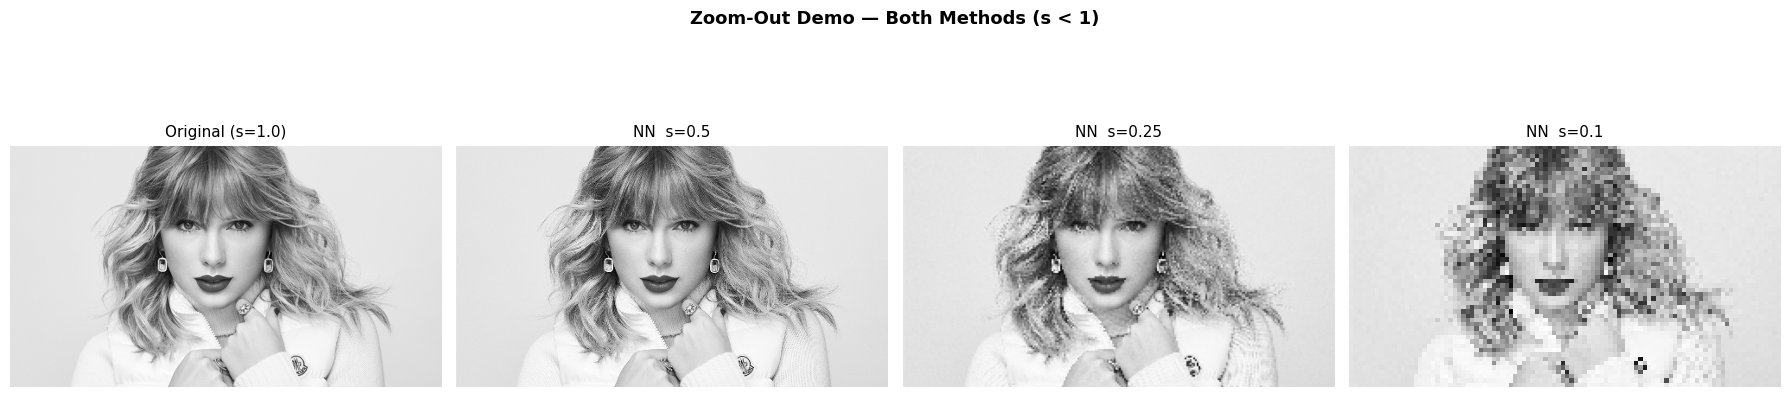

In [37]:
# ── Demonstrate zoom-out (s < 1) ────────────────────────────────────────────
img_demo = cv.imread(os.path.join(ZOOM_DIR, 'taylor.jpg'), cv.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Zoom-Out Demo — Both Methods (s < 1)', fontsize=13, fontweight='bold')

scales = [1.0, 0.5, 0.25, 0.1]
titles = ['Original (s=1.0)', 'NN  s=0.5', 'NN  s=0.25', 'NN  s=0.1']

for ax, s, title in zip(axes, scales, titles):
    if s == 1.0:
        ax.imshow(img_demo, cmap='gray', vmin=0, vmax=255)
    else:
        zoomed = zoom_image(img_demo, scale=s, method='nearest')
        ax.imshow(zoomed, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=11); ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/q7/q7_zoom_out_demo.png', dpi=150, bbox_inches='tight')
plt.show()


In [38]:
# ── Final summary table — all 5 pairs ───────────────────────────────────────
print('{:<28} {:>6} {:>12} {:>16} {:>13}'.format(
    'Small Image', 'Scale', 'SSD (NN)', 'SSD (Bilinear)', 'Improvement%'))
print('-' * 80)
for r in results:
    improv = 100 * (r['ssd_nn'] - r['ssd_bl']) / r['ssd_nn']
    print('{:<28} {:>6.1f}x {:>12.2f} {:>16.2f} {:>12.1f}%'.format(
        r['small'], r['scale'], r['ssd_nn'], r['ssd_bl'], improv))

print()
print('Bilinear consistently achieves lower SSD across all pairs.')
print('Improvement is largest at x4 zoom (~22-24%) and smaller at x20 (~10%).')


Small Image                   Scale     SSD (NN)   SSD (Bilinear)  Improvement%
--------------------------------------------------------------------------------
im01small.png                   4.0x       256.82           201.35         21.6%
im02small.png                   4.0x        65.42            49.65         24.1%
im03small.png                   4.0x       126.33            95.87         24.1%
taylor_small.jpg                5.0x       319.31           286.68         10.2%
taylor_very_small.jpg          20.0x       721.89           646.06         10.5%

Bilinear consistently achieves lower SSD across all pairs.
Improvement is largest at x4 zoom (~22-24%) and smaller at x20 (~10%).
